<a href="https://colab.research.google.com/github/surekhagm16/MLProjects/blob/main/computervision(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers

In [ ]:
#This is a dataset of 60,000 28x28 grayscale images of 10 fashion categories, along with a test set of 10,000 images. This dataset can be used as a drop-in replacement for MNIST.
fashion_mnist = tf.keras.datasets.fashion_mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
X_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [ ]:
import numpy as np
index= 0
np.set_printoptions(linewidth=320)
#print the label and the image
print(f'label: {y_train[index]}')
print(f'\nImage Pixel Array:\n\n{X_train[index]}')

label: 9

Image Pixel Array:

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1 

In [ ]:
# Normalize the training and test data sets
X_train = X_train /255.0
X_test = X_test / 255.0

In [ ]:
model = tf.keras.Sequential([
    layers.Input(shape= (28,28,1)),# 1 to indicate gray scale
    layers.Conv2D(64,(3,3), activation = 'relu'),
    layers.MaxPool2D(2,2),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPool2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243,786 (952.29 KB)

 Trainable params: 243,786 (952.29 KB)

 Non-trainable params: 0 (0.00 B)

## Output shape and params
Conv2d layer ->
filter is 3 X 3, shape is(28-3+1, 28-3+1, 64 filter) => (26, 26, 64)
params (3 X 3 filter) -> (3*3 + 1) * 64 --> 640

Conv2d_1 layer
Output shape -> (13-3+1, 13-3+1) => ( 11, 11, 64)
params ((3*3 *64 (from previous layer)) +1 ) *64 => 36,928

dense layer
shape (number of neurons) -> 128
params -> 1600 * 128 + 128 = 204928

dense1 layer
shape (number of neurons) -> 10
params -> 10 * 128 + 10 -> 1290


In [ ]:
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy,
              optimizer = tf.keras.optimizers.Adam(),
              metrics = ['accuracy'])

In [ ]:
# Call back
class mycallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epochs, logs=None):
    if logs['loss'] < 0.1:
      print('Loss is low hence cancelling the training.......')
      self.model.stop_training = True




In [ ]:
model.fit(X_train, y_train, epochs = 10, callbacks=[mycallback()])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 45ms/step - accuracy: 0.7832 - loss: 0.6012
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 139s 44ms/step - accuracy: 0.8916 - loss: 0.2953
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 44ms/step - accuracy: 0.9084 - loss: 0.2475
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9204 - loss: 0.2140
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9299 - loss: 0.1893
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9370 - loss: 0.1645
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 43ms/step - accuracy: 0.9479 - loss: 0.1385
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9553 - loss: 0.1201
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9589 - loss: 0.1088
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9658 - loss: 0.0909Loss is low hence cancelling the training.......
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 43ms/step - a

#Visualizing the convolutions and pooling

In [ ]:
print(f'print first 100 labels: {y_test[:100]}')

print first 100 labels: [9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1 4 6 0 9 3 8 8 3 3 8 0 7 5 7 9 6 1 3 7 6 7 2 1 2 2 4 4 5 8 2 2 8 4 8 0 7 7 8 5 1 1 2 3 9 8 7 0 2 6 2 3 1 2 8 4 1 8 5 9 5 0 3 2 0 6 5 3 6 7 1 8 0 1 4 2]


In [ ]:
print(f'\n shoes : {[i for i in range(100) if y_test[:100][i] ==9]}')


 shoes : [0, 23, 28, 39, 68, 83]


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)


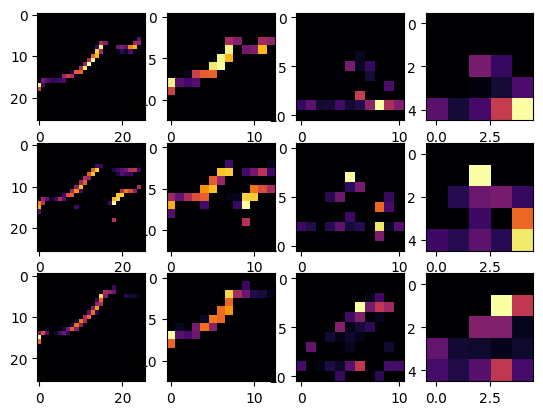

In [ ]:
first_image = 0
second_image = 23
third_image = 28
convolution_number = 1

layers_to_visualize = [tf.keras.layers.Conv2D, tf.keras.layers.MaxPool2D]
layer_outputs = [layer.output for layer in model.layers if type(layer) in layers_to_visualize]
Activation_model = tf.keras.models.Model(inputs = model.inputs, outputs = layer_outputs)

f, axarr = plt.subplots(3, len(layer_outputs))

for x in range(len(layer_outputs)):
  f1 = Activation_model.predict(X_test[first_image].reshape(1,28,28,1), verbose = False)[x]
  axarr[0,x].imshow(f1[0,:,:, convolution_number], cmap='inferno')
  axarr[0,x].grid(False)

  f2 = Activation_model.predict(X_test[second_image].reshape(1,28,28,1), verbose = False)[x]
  axarr[1,x].imshow(f2[0,:,:, convolution_number], cmap='inferno')
  axarr[1,x].grid(False)

  f3 = Activation_model.predict(X_test[third_image].reshape(1,28,28,1), verbose = False)[x]
  axarr[2,x].imshow(f3[0,:,:, convolution_number], cmap='inferno')
  axarr[2,x].grid(False)


